In [1]:
from pathlib import Path
import pandas as pd
import nibabel as nib
import numpy as np

combine_runs_file_path = Path("/Users/clairenastaskin/data/sub-Forest001/combine_runs_individual_digit")
run01 = Path("/Users/clairenastaskin/data/sub-Forest001/2026-02-25/individual_digit_movement_ARIA_software")
run02 = Path("/Users/clairenastaskin/data/sub-Forest001/2026-02-26/shallow_individual_digit_contin_1.6s_069a0905-0992-72de-8000-35ea791279e6")
file_name = 'fusi_run_clean.nii.gz' # Upload runs after temporal boxcar smoothing, 

# Load fUSI nifti file and get data into a numpy array
nifti_img1 = nib.load(run01 / file_name)
fusi_data1 = nifti_img1.get_fdata()
print('first run shape:', fusi_data1.shape)

nifti_img2 = nib.load(run02 / file_name)
fusi_data2 = nifti_img2.get_fdata()
print('second run shape:', fusi_data2.shape)

fusi_indices_retained_1 = nib.load(run01 / "fusi_indices_retained_volumes.nii.gz").get_fdata().astype(int)
fusi_indices_retained_2 = nib.load(run02 / "fusi_indices_retained_volumes.nii.gz").get_fdata().astype(int)
print(f"Run01: {fusi_data1.shape[3]} total frames, {len(fusi_indices_retained_1)} good frames")
print(f"Run02: {fusi_data2.shape[3]} total frames, {len(fusi_indices_retained_2)} good frames")

mask_path = next(run01.glob("*mask.nii.gz"))
nifti_mask = nib.load(mask_path)
mask = nifti_mask.get_fdata()
print('mask shape:', mask.shape)

first run shape: (113, 55, 50, 385)
second run shape: (113, 55, 50, 415)
Run01: 385 total frames, 331 good frames
Run02: 415 total frames, 375 good frames
mask shape: (113, 55, 50)


In [2]:
import ants
import warnings
from nilearn.image import mean_img, resample_img

def nib_to_ants(nib_img):
    """Convert a nibabel image to an ANTs image."""
    data = nib_img.get_fdata().astype(np.float32)
    affine = nib_img.affine
    img = ants.from_numpy(data)
    img.set_direction(affine[:3, :3] / np.abs(affine[:3, :3]).max(axis=0))
    img.set_origin(affine[:3, 3].tolist())
    img.set_spacing(np.abs(np.diag(affine[:3, :3])).tolist())
    return img


mean_run01 = np.nanmean(fusi_data1[:,:,:,fusi_indices_retained_1], axis=3)
mean_run02 = np.nanmean(fusi_data2[:,:,:,fusi_indices_retained_2], axis=3)

# Apply brain mask to both means before registration
mean_run01_brain = mean_run01 * mask
mean_run02_brain = mean_run02 * mask

# Convert to ANTs images
fixed = nib_to_ants(nib.Nifti1Image(mean_run01_brain, nifti_img1.affine))
moving = nib_to_ants(nib.Nifti1Image(mean_run02_brain, nifti_img2.affine))

# Rigid registration with mutual information (robust to intensity differences)
print("Running rigid registration with mutual information...")
reg = ants.registration(
    fixed=fixed,
    moving=moving,
    type_of_transform='Rigid',
    aff_metric='mattes',
)
print("Registration complete.")

# Apply the transform to each timepoint of run02 (only good frames)
print("Applying transform to good frames of run02...")
fusi_data2_good = np.nan_to_num(fusi_data2[:,:,:,fusi_indices_retained_2])
registered_frames = []
for t in range(fusi_data2_good.shape[3]):
    frame = nib_to_ants(nib.Nifti1Image(fusi_data2_good[:,:,:,t], nifti_img2.affine))
    warped = ants.apply_transforms(fixed, frame, reg['fwdtransforms'])
    registered_frames.append(warped.numpy())

fusi_data2_registered = np.stack(registered_frames, axis=3)
print(f"Registered run02 shape: {fusi_data2_registered.shape}")

# Subsample run01 to good frames only
fusi_data1_good = np.nan_to_num(fusi_data1[:,:,:,fusi_indices_retained_1])

# Build NIfTI images for GLM (subsampled to match design matrices)
fusi_img = [
    nib.Nifti1Image(fusi_data1_good, nifti_img1.affine, nifti_img1.header),
    nib.Nifti1Image(fusi_data2_registered, nifti_img1.affine, nifti_img1.header),
]
print(f"First run shape: {fusi_img[0].shape}")
print(f"Second run shape (registered): {fusi_img[1].shape}")

# Save run01 and registered run02 to combine_runs_file_path
combine_runs_file_path.mkdir(parents=True, exist_ok=True)
nib.save(fusi_img[0], combine_runs_file_path / 'run01_clean.nii.gz')
nib.save(fusi_img[1], combine_runs_file_path / 'run02_registered_clean.nii.gz')
print(f"Saved run01 and registered run02 to {combine_runs_file_path}")

/Users/clairenastaskin/Documents/Anise/.venv/lib/python3.9/site-packages/urllib3/__init__.py:35: NotOpenSSLWarning: urllib3 v2 only supports OpenSSL 1.1.1+, currently the 'ssl' module is compiled with 'LibreSSL 2.8.3'. See: https://github.com/urllib3/urllib3/issues/3020
  warnings.warn(


Running rigid registration with mutual information...
Registration complete.
Applying transform to good frames of run02...
Registered run02 shape: (113, 55, 50, 375)
First run shape: (113, 55, 50, 331)
Second run shape (registered): (113, 55, 50, 375)
Saved run01 and registered run02 to /Users/clairenastaskin/data/sub-Forest001/combine_runs_individual_digit


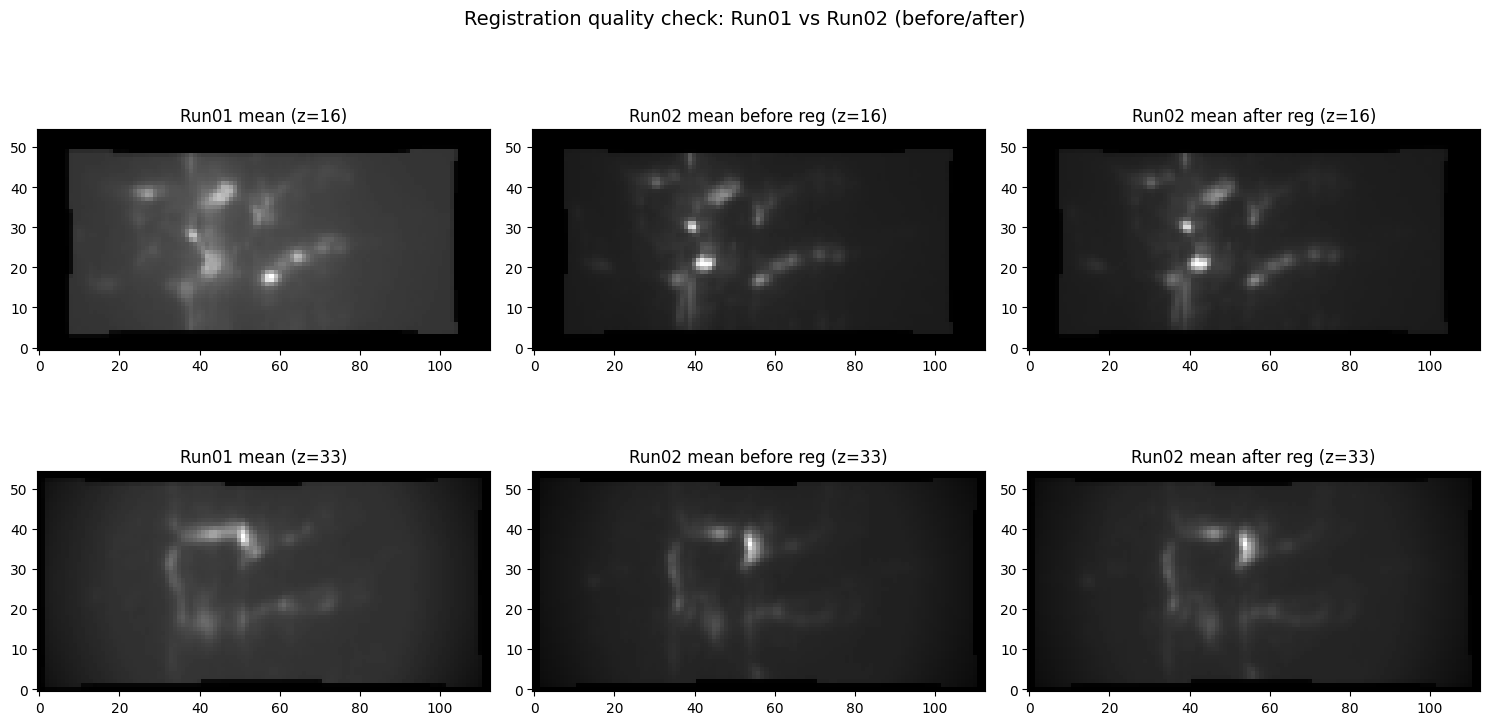

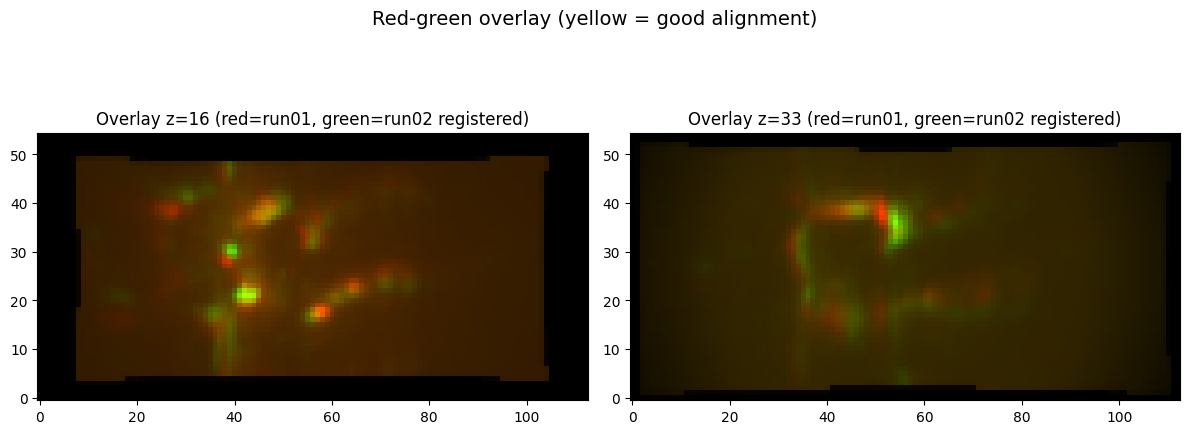

In [4]:
import matplotlib.pyplot as plt

# Compute mean of registered run02 for comparison
mean_run02_registered = np.mean(fusi_data2_registered[:,:,:,fusi_indices_retained_2], axis=3)

# Pick two slices along the z-axis (elevation) for visualization
z_slices = [fusi_data1.shape[2] // 3, 2 * fusi_data1.shape[2] // 3]

fig, axes = plt.subplots(2, 3, figsize=(15, 8))
for row, z in enumerate(z_slices):
    # Run01 mean
    axes[row, 0].imshow(mean_run01[:, :, z].T, cmap='gray', origin='lower')
    axes[row, 0].set_title(f'Run01 mean (z={z})')

    # Run02 mean BEFORE registration
    axes[row, 1].imshow(mean_run02[:, :, z].T, cmap='gray', origin='lower')
    axes[row, 1].set_title(f'Run02 mean before reg (z={z})')

    # Run02 mean AFTER registration
    axes[row, 2].imshow(mean_run02_registered[:, :, z].T, cmap='gray', origin='lower')
    axes[row, 2].set_title(f'Run02 mean after reg (z={z})')

plt.suptitle('Registration quality check: Run01 vs Run02 (before/after)', fontsize=14)
plt.tight_layout()
plt.show()

# Overlay: run01 in red, registered run02 in green
fig, axes = plt.subplots(1, 2, figsize=(12, 5))
for col, z in enumerate(z_slices):
    # Normalize both to [0, 1] for overlay
    r = mean_run01[:, :, z].T.copy()
    g = mean_run02_registered[:, :, z].T.copy()
    r = (r - r.min()) / (r.max() - r.min() + 1e-8)
    g = (g - g.min()) / (g.max() - g.min() + 1e-8)
    overlay = np.stack([r, g, np.zeros_like(r)], axis=-1)
    axes[col].imshow(overlay, origin='lower')
    axes[col].set_title(f'Overlay z={z} (red=run01, green=run02 registered)')

plt.suptitle('Red-green overlay (yellow = good alignment)', fontsize=14)
plt.tight_layout()
plt.show()

In [5]:
mean_image = mean_img(fusi_img, copy_header=True)
print(f"Mean image shape: {mean_image.shape}")

Mean image shape: (113, 55, 50)


In [6]:
# repetition time, in seconds
t_r = run01 / 't_r.npy'
# Sample at the beginning of each acquisition.
slice_time_ref = 0.0
# We use a discrete cosine transform to model signal drifts.
drift_model = "Cosine"
# The cutoff for the drift model is 0.01 Hz.
high_pass = 0.01
# The hemodynamic response function
hrf_model = "spm + derivative"

In [7]:
import numpy as np
import pandas as pd
from numpy import load
from nilearn.glm.first_level import make_first_level_design_matrix

# Load design matrices with recation time taken into account already 
design_matrices = []
design_matrix_1 = load(run01 / 'design_matrix.npz', allow_pickle=True)
design_matrix_2 = load(run02 / 'design_matrix.npz', allow_pickle=True)

# Extract the design matrices and column names from the npz files
dm1 = pd.DataFrame(design_matrix_1['design_matrix'], columns=design_matrix_1['column_names'])
dm2 = pd.DataFrame(design_matrix_2['design_matrix'], columns=design_matrix_2['column_names'])

design_matrices = [dm1, dm2]
for i, dm in enumerate(design_matrices, 1):
    print(f"Design matrix {i} shape: {dm.shape}")

Design matrix 1 shape: (331, 42)
Design matrix 2 shape: (375, 43)


/var/folders/50/vlgy95sd2d1d6w1_l8pgqd1c0000gn/T/ipykernel_10895/341075645.py:5: DeprecationWarning: The parameter "ax" will be removed in 0.13.0 release of Nilearn. Please use the parameter "axes" instead.
  plot_design_matrix(design_matrices[0], ax=axes[0])
/var/folders/50/vlgy95sd2d1d6w1_l8pgqd1c0000gn/T/ipykernel_10895/341075645.py:7: DeprecationWarning: The parameter "ax" will be removed in 0.13.0 release of Nilearn. Please use the parameter "axes" instead.
  plot_design_matrix(design_matrices[1], ax=axes[1])
/var/folders/50/vlgy95sd2d1d6w1_l8pgqd1c0000gn/T/ipykernel_10895/341075645.py:10: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  fig.show()


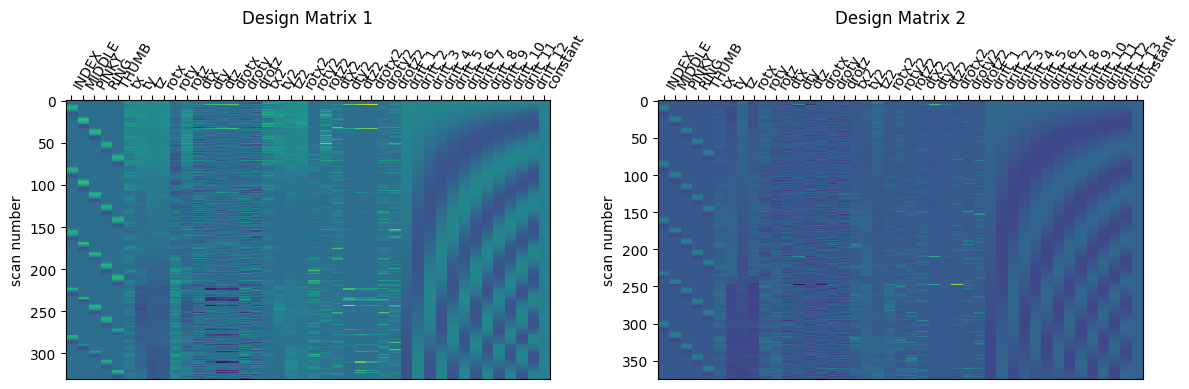

In [9]:
import matplotlib.pyplot as plt
from nilearn.plotting import plot_design_matrix

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
plot_design_matrix(design_matrices[0], ax=axes[0])
axes[0].set_title('Design Matrix 1')
plot_design_matrix(design_matrices[1], ax=axes[1]) 
axes[1].set_title('Design Matrix 2')
plt.tight_layout()
fig.show()

In [10]:
##########################################
## Create contrasts for localizer task ##
##########################################

def find_all_localizer_contrasts(design_matrices):
    contrast_list = []
    contrasts = []

    for i in range(len(design_matrices)):
        # Get column names excluding motion parameters and drifts
        contrast = [col for col in design_matrices[i].columns 
                    if not col.startswith(('rot', 'drift')) 
                    and col not in ['constant', 'tx', 'ty', 'tz']]
        contrasts.append(contrast)
        
        # Add unique names to overall contrast list
        contrast_list.extend([c for c in contrast if c not in contrast_list])

    contrast_matrix = np.eye(len(contrast_list))
    contrasts = {
        column: contrast_matrix[i]
        for i, column in enumerate(contrast_list)
    }
    return contrasts
    
contrasts = find_all_localizer_contrasts(design_matrices)
print(contrasts)

{'INDEX': array([1., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
       0., 0., 0.]), 'MIDDLE': array([0., 1., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
       0., 0., 0.]), 'PINKY': array([0., 0., 1., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
       0., 0., 0.]), 'RING': array([0., 0., 0., 1., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
       0., 0., 0.]), 'THUMB': array([0., 0., 0., 0., 1., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
       0., 0., 0.]), 'dtx': array([0., 0., 0., 0., 0., 1., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
       0., 0., 0.]), 'dty': array([0., 0., 0., 0., 0., 0., 1., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
       0., 0., 0.]), 'dtz': array([0., 0., 0., 0., 0., 0., 0., 1., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
       0., 0., 0.]), 'drotx': array([0., 0., 0., 0., 0., 0., 0., 0., 1., 0., 0., 0., 0., 0., 0., 0., 0.,
       0., 0., 0.]), 'droty': array([0., 0., 0., 0., 0., 0., 0., 0., 0., 1., 0., 

In [11]:
from nilearn import plotting
from nilearn.glm.first_level import FirstLevelModel

print("Fitting a GLM")
# Load TR from run01 and convert to float
t_r = float(np.load(run01 / 't_r.npy'))
print(f"TR loaded: {t_r} seconds")

fusi_glm = FirstLevelModel(
        t_r=t_r, minimize_memory=True, hrf_model="glover", drift_model="cosine",
        high_pass=0.01, noise_model="ar1", standardize=True,
        smoothing_fwhm=2, mask_img=nifti_mask)

fusi_glm = fusi_glm.fit(fusi_img, design_matrices=design_matrices)

Fitting a GLM
TR loaded: 1.599987044 seconds


	contrast id: INDEX


/var/folders/50/vlgy95sd2d1d6w1_l8pgqd1c0000gn/T/ipykernel_10895/933157126.py:12: UserWarning: One contrast given, assuming it for all 2 runs
  z_map = fusi_glm.compute_contrast(contrast_val, output_type="z_score")
/Users/clairenastaskin/Documents/Anise/.venv/lib/python3.9/site-packages/nilearn/glm/contrasts.py:115: UserWarning: t contrasts should be of length P=42, but it has length 20. The rest of the contrast was padded with zeros.
  reg = regression_result[label_].Tcontrast(con_val)
/Users/clairenastaskin/Documents/Anise/.venv/lib/python3.9/site-packages/nilearn/glm/contrasts.py:115: UserWarning: t contrasts should be of length P=43, but it has length 20. The rest of the contrast was padded with zeros.
  reg = regression_result[label_].Tcontrast(con_val)


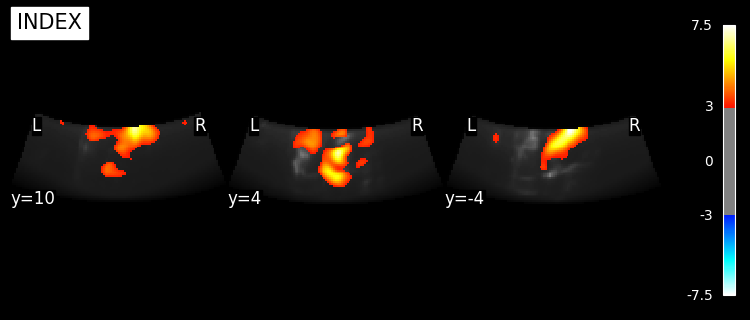

	contrast id: MIDDLE


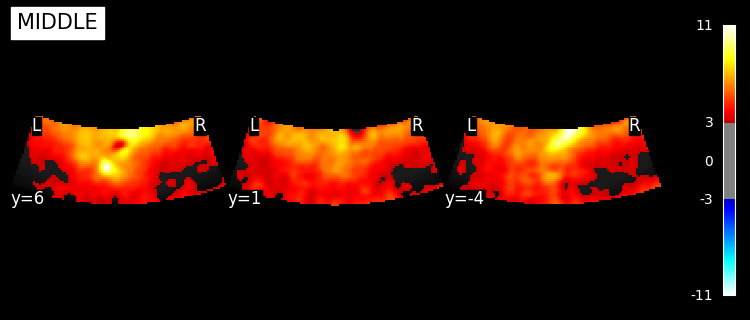

	contrast id: PINKY


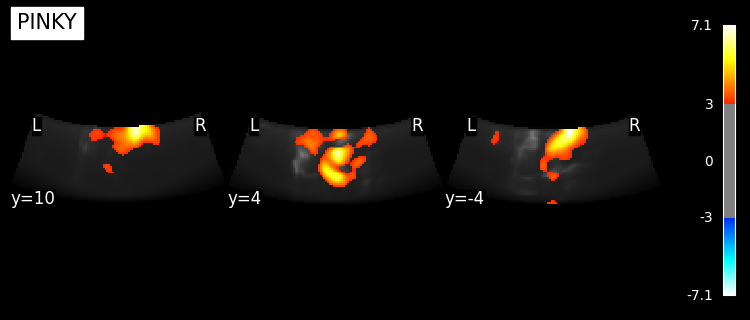

	contrast id: RING


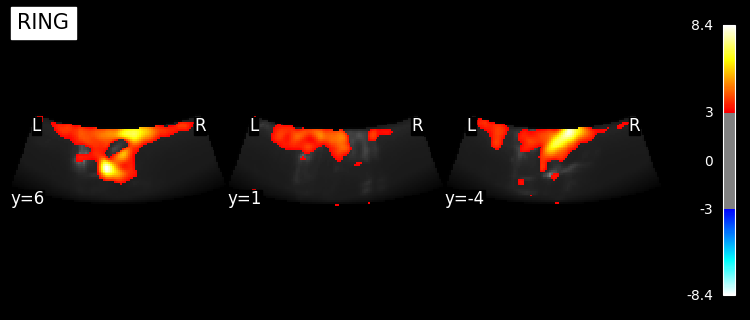

	contrast id: THUMB


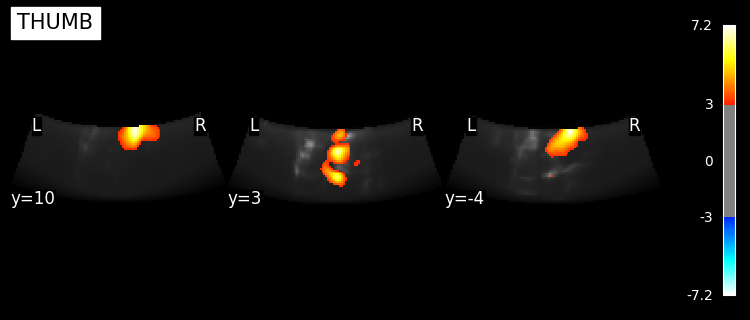

In [12]:
import os

affine_global = nifti_img1.affine

# Iterate on contrasts
for contrast_id, contrast_val in contrasts.items():
    if contrast_id.startswith(("drift_", "tx", "ty", "tz", "rot", "dt", "drot")):
        continue

    print(f"\tcontrast id: {contrast_id}")
    # compute the contrasts
    z_map = fusi_glm.compute_contrast(contrast_val, output_type="z_score")
        # Get the data from z_map and create new NIfTI image
    z_map_data = z_map.get_fdata()
    nii_zmap = nib.Nifti1Image(z_map_data, affine_global)
    # Save the NIfTI zmap to a compressed .nii.gz file in the base_path
    output_path = os.path.join(combine_runs_file_path, f"{contrast_id}_z_map.nii.gz")
    nib.save(nii_zmap, output_path)
    

    plotting.plot_stat_map(
        z_map,
        bg_img=mean_image,
        threshold=3.0,
        display_mode="y",
        cut_coords=3,
        black_bg=True,
        title=contrast_id,
    )
    plotting.show()